<a href="https://colab.research.google.com/github/fcoliveira-utfpr/relacoes_fisicas_ambiente/blob/main/codigos_python/aula_irrigacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Manejo da irrigação pelo balanço hídrico · notebook auxiliar

Este notebook acompanha o roteiro da aula e tem duas partes:

| Parte | Conteúdo |
|---|---|
| **1. Exemplo da aula** | Os 30 dias do exemplo resolvido: turno de rega variável, fixo e antecipado, tabelas diárias (com exportação para LaTeX), painéis de monitoramento e análise de sensibilidade |
| **2. Uma safra real** | Soja em Medianeira-PR (2023/24) com dados do BR-DWGD: ETo de Penman-Monteith, Kc da FAO-56, raiz crescendo, AFD ajustada à demanda e monitoramento diário ao longo do ciclo |

**Formulação do balanço (depleção da zona radicular, FAO-56):**

- Dr,i = Dr,i−1 + ETc,i − Pi; se Dr,i < 0, o excesso vira drenagem profunda (DP) e Dr,i = 0.
- Precipitação efetiva: Pe = P − DP, equivalente a Pe = mín[P; ETc + Σ(ETc − Pe)i−1].
- Na irrigação: IRN = Dr; ITN = IRN/Ea; Ti = ITN/Ia; depois, Dr = 0.
- Armazenamento: ARM = CAD − Dr. Coeficiente de estresse: Ks = (CAD − Dr)/[(1 − f) · CAD] quando Dr > AFD.

# 0. Bibliotecas
___

In [1]:
!pip install -q agrometeorologiapy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import agrometeorologiapy as amp

PASTA_FIG = 'figuras'
os.makedirs(PASTA_FIG, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})

CORES = {'P': '#4292c6', 'I': '#41ab5d', 'ETc': '#d7301f', 'DP': '#8c6bb1',
         'Dr': '#08306b', 'conforto': '#e5f5e0', 'estresse': '#fee6ce', 'murcha': '#fcbba1'}


def salvar(fig, nome):
    caminho = os.path.join(PASTA_FIG, nome)
    fig.savefig(caminho, dpi=200, bbox_inches='tight')
    print('Figura salva em:', caminho)


def hhmm(horas):
    """Converte horas decimais em H:MM."""
    if horas <= 0:
        return '—'
    m = int(round(horas * 60))
    return f'{m // 60}:{m % 60:02d}'

# 1. O balanço hídrico diário
___

Uma única função atende aos três critérios de irrigação:

| Critério | Regra |
|---|---|
| `'variavel'` | Irriga quando Dr ≥ AFD |
| `'antecipado'` | Irriga quando Dr + ETc do dia seguinte ≥ AFD (evita passar da AFD) |
| `'fixo'` | Irriga a cada `TR` dias, repondo Dr; cancela se Dr = 0 |
| `'nenhum'` | Sem irrigação (sequeiro) |

Opções:

- `CAD` pode ser um número ou uma série (raiz crescendo ao longo do ciclo).
- `f_ajustado=True` aplica o ajuste da FAO-56: f = f_tab + 0,04 · (5 − ETc), limitado entre 0,1 e 0,8.
- `ultimo_dia` (número do dia, contado a partir de 1) suspende a irrigação a partir dessa data, como se faz na maturação.
- `ajustar_ks=True` usa ETc · Ks no balanço quando a cultura está em estresse (mais realista sem irrigação). Com `False`, reproduz as tabelas do roteiro.

In [2]:
def balanco_irrigacao(dados, CAD, f=0.5, criterio='variavel', TR=3, Ea=0.82, Ia=22.0,
                      f_ajustado=False, ajustar_ks=False, Dr_inicial=0.0, ultimo_dia=None):
    """Balanço hídrico diário para manejo da irrigação (depleção da zona radicular).

    dados : DataFrame com índice de datas e colunas 'P' e 'ETc' (mm/d)
    CAD   : capacidade de água disponível (mm), número ou série alinhada a 'dados'
    Retorna um DataFrame com Pe, Dr, AFD, ARM, Ks, DP, IRN, ITN e Ti por dia.
    """
    d = dados.copy()
    n = len(d)
    cad = np.full(n, float(CAD)) if np.isscalar(CAD) else np.asarray(CAD, dtype=float)
    etc_pot = d['ETc'].to_numpy(dtype=float)
    p = d['P'].to_numpy(dtype=float)

    f_dia = np.clip(f + 0.04 * (5 - etc_pot), 0.1, 0.8) if f_ajustado else np.full(n, f)
    afd = f_dia * cad

    col = {k: np.zeros(n) for k in ['Dr', 'DP', 'IRN', 'Ks', 'ETc_aj', 'Soma_ini']}
    dr = Dr_inicial
    for i in range(n):
        col['Soma_ini'][i] = dr

        # Coeficiente de estresse com a depleção do início do dia
        ks = 1.0 if dr <= afd[i] else max(0.0, (cad[i] - dr) / ((1 - f_dia[i]) * cad[i]))
        etc_i = etc_pot[i] * ks if ajustar_ks else etc_pot[i]

        dr = dr + etc_i - p[i]
        dp = 0.0
        if dr < 0:                                   # excesso de chuva: drenagem profunda
            dp, dr = -dr, 0.0
        dr = min(dr, cad[i])                         # depleção não passa da CAD

        if criterio == 'variavel':
            irrigar = dr >= afd[i]
        elif criterio == 'antecipado':
            etc_amanha = etc_pot[i + 1] if i + 1 < n else etc_pot[i]
            irrigar = dr + etc_amanha >= afd[i]
        elif criterio == 'fixo':
            irrigar = ((i + 1) % TR == 0) and dr > 0
        elif criterio == 'nenhum':
            irrigar = False
        else:
            raise ValueError("criterio deve ser 'variavel', 'antecipado', 'fixo' ou 'nenhum'")
        if ultimo_dia is not None and i + 1 > ultimo_dia:
            irrigar = False

        col['Dr'][i], col['DP'][i] = dr, dp
        col['IRN'][i] = dr if irrigar else 0.0
        col['Ks'][i] = 1.0 if dr <= afd[i] else max(0.0, (cad[i] - dr) / ((1 - f_dia[i]) * cad[i]))
        col['ETc_aj'][i] = etc_i
        if irrigar:
            dr = 0.0

    d['CAD'] = cad
    d['f'] = f_dia
    d['AFD'] = afd
    d['Pe'] = p - col['DP']
    d['ETc-Pe'] = col['ETc_aj'] - d['Pe']
    d['Soma'] = col['Dr']                            # Σ(ETc − Pe) = depleção no fim do dia
    d['Dr'] = col['Dr']
    d['ARM'] = cad - col['Dr']
    d['Ks'] = col['Ks']
    d['DP'] = col['DP']
    d['IRN'] = col['IRN']
    d['ITN'] = d['IRN'] / Ea
    d['Ti_h'] = d['ITN'] / Ia
    d['Ti'] = d['Ti_h'].apply(hhmm)
    d['ETr'] = col['ETc_aj']                         # ETc ajustada pelo estresse (se ajustar_ks)
    return d


def resumo(b, nome=''):
    """Indicadores do período."""
    return pd.Series({
        'Irrigações': int((b['IRN'] > 0).sum()),
        'IRN total (mm)': b['IRN'].sum(),
        'ITN total (mm)': b['ITN'].sum(),
        'Tempo total': hhmm(b['Ti_h'].sum()),
        'Chuva (mm)': b['P'].sum(),
        'Chuva efetiva (mm)': b['Pe'].sum(),
        'Drenagem profunda (mm)': b['DP'].sum(),
        'ETc (mm)': b['ETc'].sum(),
        'ETr (mm)': b['ETr'].sum(),
        'Dias com Dr > AFD': int((b['Dr'] > b['AFD'] + 1e-9).sum()),
        'Ks mínimo': b['Ks'].min(),
    }, name=nome)

# 2. Parte 1 · Exemplo da aula
___

AFD = 13 mm (CAD = 26 mm, f = 0,5), Ea = 0,82, Ia = 22 mm h⁻¹, solo na capacidade de campo no início.

In [34]:
P = [16.81, 1.64, 29.85, 0, 0, 0, 0, 0, 0, 0, 3.18, 14.49, 0, 0, 0,
     0, 0, 0, 0, 0, 0, 1.59, 1.86, 3.53, 0, 0, 0, 0, 0, 0]
ETo = [3.4, 4.2, 4.3, 5.2, 5.8, 6.0, 5.9, 6.3, 5.7, 5.1, 3.8, 3.2, 6.0, 6.5, 6.3,
       5.2, 4.7, 3.3, 5.4, 4.7, 4.4, 4.2, 3.9, 4.8, 4.8, 5.9, 5.6, 4.5, 5.2, 4.8]
Kc = [0.30] * 6 + [0.80] * 8 + [0.90] * 12 + [0.53] * 4

ex = pd.DataFrame({'P': P, 'ETo': ETo, 'Kc': Kc},
                  index=pd.date_range('2026-04-24', periods=30, name='Data'))
ex['ETc'] = (ex['ETo'] * ex['Kc']).round(2)
ex.insert(0, 'DAE', range(1, len(ex) + 1))

CAD_EX, F_EX, EA_EX, IA_EX = 26.0, 0.5, 0.82, 22.0

trv = balanco_irrigacao(ex, CAD_EX, F_EX, 'variavel', Ea=EA_EX, Ia=IA_EX)
trf = balanco_irrigacao(ex, CAD_EX, F_EX, 'fixo', TR=3, Ea=EA_EX, Ia=IA_EX)
tra = balanco_irrigacao(ex, CAD_EX, F_EX, 'antecipado', Ea=EA_EX, Ia=IA_EX)

# Conferência com as tabelas do roteiro (vale só para os dados originais)
if abs(trv['IRN'].sum() - 93.28) < 0.01 and abs(trf['IRN'].sum() - 91.74) < 0.01:
    print('Totais conferem com o roteiro ✔')
else:
    print('Dados diferentes do roteiro: totais recalculados para os novos valores.')
print(f"TR variável: {(trv['IRN'] > 0).sum()} irrigações, IRN = {trv['IRN'].sum():.2f} mm")
print(f"TR fixo:     {(trf['IRN'] > 0).sum()} irrigações, IRN = {trf['IRN'].sum():.2f} mm")

COLS = ['DAE', 'P', 'ETo', 'Kc', 'ETc', 'Pe', 'ETc-Pe', 'Soma', 'IRN', 'ITN', 'Ti_h', 'Ti']
trv[COLS].round(2)

Dados diferentes do roteiro: totais recalculados para os novos valores.
TR variável: 5 irrigações, IRN = 77.84 mm
TR fixo:     8 irrigações, IRN = 84.94 mm


,DAE,P,ETo,Kc,ETc,Pe,ETc-Pe,Soma,IRN,ITN,Ti_h,Ti
Data,,,,,,,,,,,,
2026-04-24,1,16.81,3.4,0.30,1.02,1.02,0.00,0.00,0.00,0.00,0.00,—
2026-04-25,2,1.64,4.2,0.30,1.26,1.26,0.00,0.00,0.00,0.00,0.00,—
2026-04-26,3,29.85,4.3,0.30,1.29,1.29,0.00,0.00,0.00,0.00,0.00,—
2026-04-27,4,0.00,5.2,0.30,1.56,0.00,1.56,1.56,0.00,0.00,0.00,—
2026-04-28,5,0.00,5.8,0.30,1.74,0.00,1.74,3.30,0.00,0.00,0.00,—
2026-04-29,6,0.00,6.0,0.30,1.80,0.00,1.80,5.10,0.00,0.00,0.00,—
2026-04-30,7,0.00,5.9,0.80,4.72,0.00,4.72,9.82,0.00,0.00,0.00,—
2026-05-01,8,0.00,6.3,0.80,5.04,0.00,5.04,14.86,14.86,18.12,0.82,0:49
2026-05-02,9,0.00,5.7,0.80,4.56,0.00,4.56,4.56,0.00,0.00,0.00,—


## 2.1 Comparação dos critérios

In [35]:
comp = pd.concat([resumo(trv, 'TR variável'), resumo(trf, 'TR fixo (3 dias)'),
                  resumo(tra, 'TR antecipado')], axis=1)
comp

,TR variável,TR fixo (3 dias),TR antecipado
Irrigações,5,8,8
IRN total (mm),77.84,84.94,84.94
ITN total (mm),94.926829,103.585366,103.585366
Tempo total,4:19,4:43,4:43
Chuva (mm),72.95,72.95,72.95
Chuva efetiva (mm),24.79,20.23,20.23
Drenagem profunda (mm),48.16,52.72,52.72
ETc (mm),105.17,105.17,105.17
ETr (mm),105.17,105.17,105.17
Dias com Dr > AFD,5,3,0


## 2.3 Painel de monitoramento diário

Quatro painéis com o mesmo eixo de datas:

- **(a) Entradas e saídas:** chuva e irrigação (barras) e ETc (linha).
- **(b) Depleção:** Dr com as faixas de conforto (até a AFD), estresse (AFD a CAD) e o eixo invertido, como um "termômetro" de secagem do solo. Triângulos marcam as irrigações.
- **(c) Coeficiente de estresse (Ks):** dias abaixo de 1 indicam perda de transpiração.
- **(d) Acumulados:** chuva, irrigação, ETc e drenagem profunda.

Figura salva em: figuras/irrigacao_monitoramento_trv.png


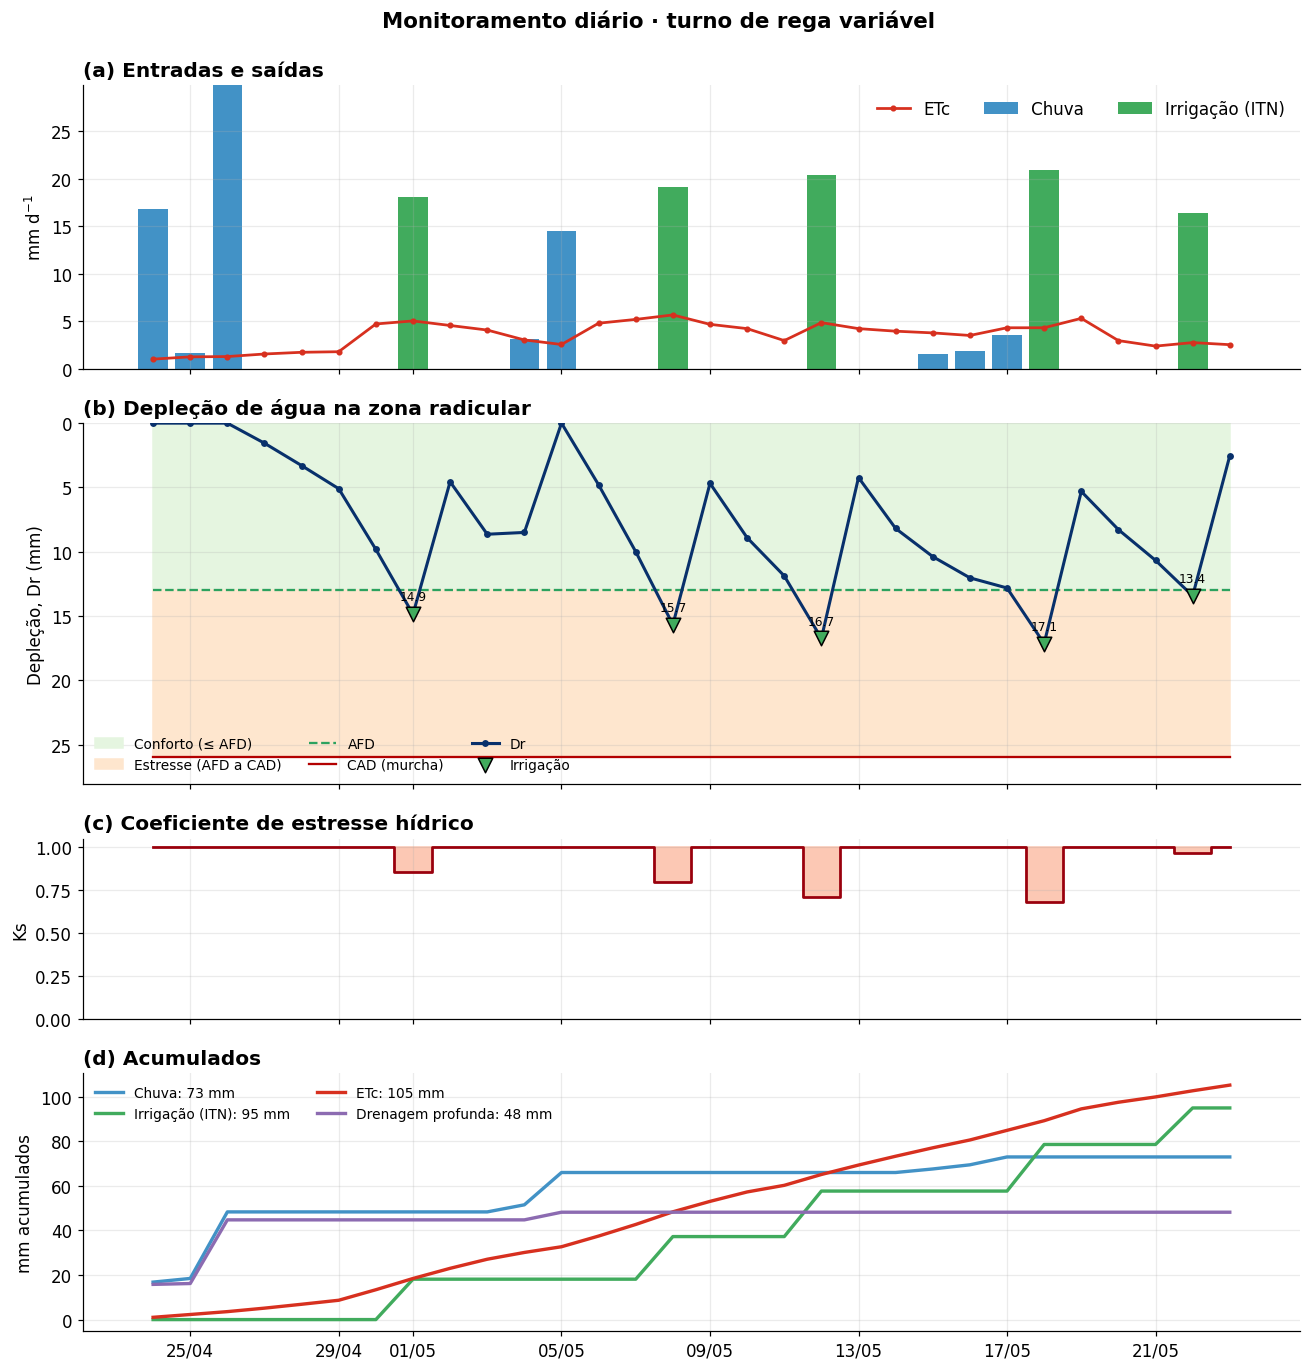

In [36]:
def painel_monitoramento(b, titulo, arquivo=None, marcar_hoje=None):
    fig, ax = plt.subplots(4, 1, figsize=(12, 12.5), sharex=True,
                           gridspec_kw={'height_ratios': [1.1, 1.4, 0.7, 1]})
    x = b.index
    largura = 0.8 if len(b) <= 60 else 1.0

    # (a) Entradas e saídas
    ax[0].bar(x, b['P'], width=largura, color=CORES['P'], label='Chuva')
    ax[0].bar(x, b['ITN'], bottom=b['P'], width=largura, color=CORES['I'], label='Irrigação (ITN)')
    ax[0].plot(x, b['ETc'], 'o-', color=CORES['ETc'], ms=3, lw=1.8, label='ETc')
    teto = max(b['ETc'].max() * 3, 30)                 # limita o eixo em dias de chuva extrema
    total_dia = b['P'] + b['ITN']
    if total_dia.max() > teto:
        ax[0].set_ylim(0, teto)
        for d0, v in total_dia[total_dia > teto].items():
            ax[0].text(d0, teto * 0.97, f'{v:.0f}', ha='center', va='top', fontsize=8,
                       color='white', fontweight='bold', rotation=90)
    ax[0].set_ylabel('mm d$^{-1}$')
    ax[0].set_title('(a) Entradas e saídas', loc='left', fontweight='bold')
    ax[0].legend(frameon=False, ncol=3, loc='upper right')

    # (b) Depleção da zona radicular
    ax[1].fill_between(x, 0, b['AFD'], step='mid', color=CORES['conforto'], label='Conforto (≤ AFD)')
    ax[1].fill_between(x, b['AFD'], b['CAD'], step='mid', color=CORES['estresse'], label='Estresse (AFD a CAD)')
    ax[1].step(x, b['AFD'], where='mid', color='#2ca25f', lw=1.5, ls='--', label='AFD')
    ax[1].step(x, b['CAD'], where='mid', color='#b30000', lw=1.5, label='CAD (murcha)')
    ax[1].plot(x, b['Dr'], 'o-', color=CORES['Dr'], ms=3.5, lw=2, label='Dr')
    irr = b[b['IRN'] > 0]
    ax[1].scatter(irr.index, irr['Dr'], marker='v', s=90, color=CORES['I'],
                  edgecolor='black', zorder=5, label='Irrigação')
    for d0, r in irr.iterrows():
        ax[1].annotate(f"{r['IRN']:.1f}", (d0, r['Dr']), xytext=(0, 9),
                       textcoords='offset points', ha='center', fontsize=8)
    ax[1].set_ylim(b['CAD'].max() * 1.08, 0)               # eixo invertido
    ax[1].set_ylabel('Depleção, Dr (mm)')
    ax[1].set_title('(b) Depleção de água na zona radicular', loc='left', fontweight='bold')
    ax[1].legend(frameon=False, ncol=3, fontsize=9, loc='lower left')

    # (c) Coeficiente de estresse
    ax[2].fill_between(x, b['Ks'], 1, step='mid', color=CORES['murcha'], alpha=0.8)
    ax[2].step(x, b['Ks'], where='mid', color='#99000d', lw=1.8)
    ax[2].set_ylim(0, 1.05)
    ax[2].set_ylabel('Ks')
    ax[2].set_title('(c) Coeficiente de estresse hídrico', loc='left', fontweight='bold')

    # (d) Acumulados
    for col, rot, cor in [('P', 'Chuva', CORES['P']), ('ITN', 'Irrigação (ITN)', CORES['I']),
                          ('ETc', 'ETc', CORES['ETc']), ('DP', 'Drenagem profunda', CORES['DP'])]:
        ax[3].plot(x, b[col].cumsum(), lw=2.2, color=cor, label=f'{rot}: {b[col].sum():.0f} mm')
    ax[3].set_ylabel('mm acumulados')
    ax[3].set_title('(d) Acumulados', loc='left', fontweight='bold')
    ax[3].legend(frameon=False, ncol=2, fontsize=9, loc='upper left')

    if marcar_hoje is not None:
        for a in ax:
            a.axvline(pd.Timestamp(marcar_hoje), color='black', ls=':', lw=1.2)
    for a in ax:
        a.grid(alpha=0.25)
    ax[3].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=10))
    ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    fig.suptitle(titulo, fontweight='bold', fontsize=14, y=0.995)
    plt.tight_layout()
    if arquivo:
        salvar(fig, arquivo)
    plt.show()


painel_monitoramento(trv, 'Monitoramento diário · turno de rega variável',
                     'irrigacao_monitoramento_trv.png')

Figura salva em: figuras/irrigacao_monitoramento_trf.png


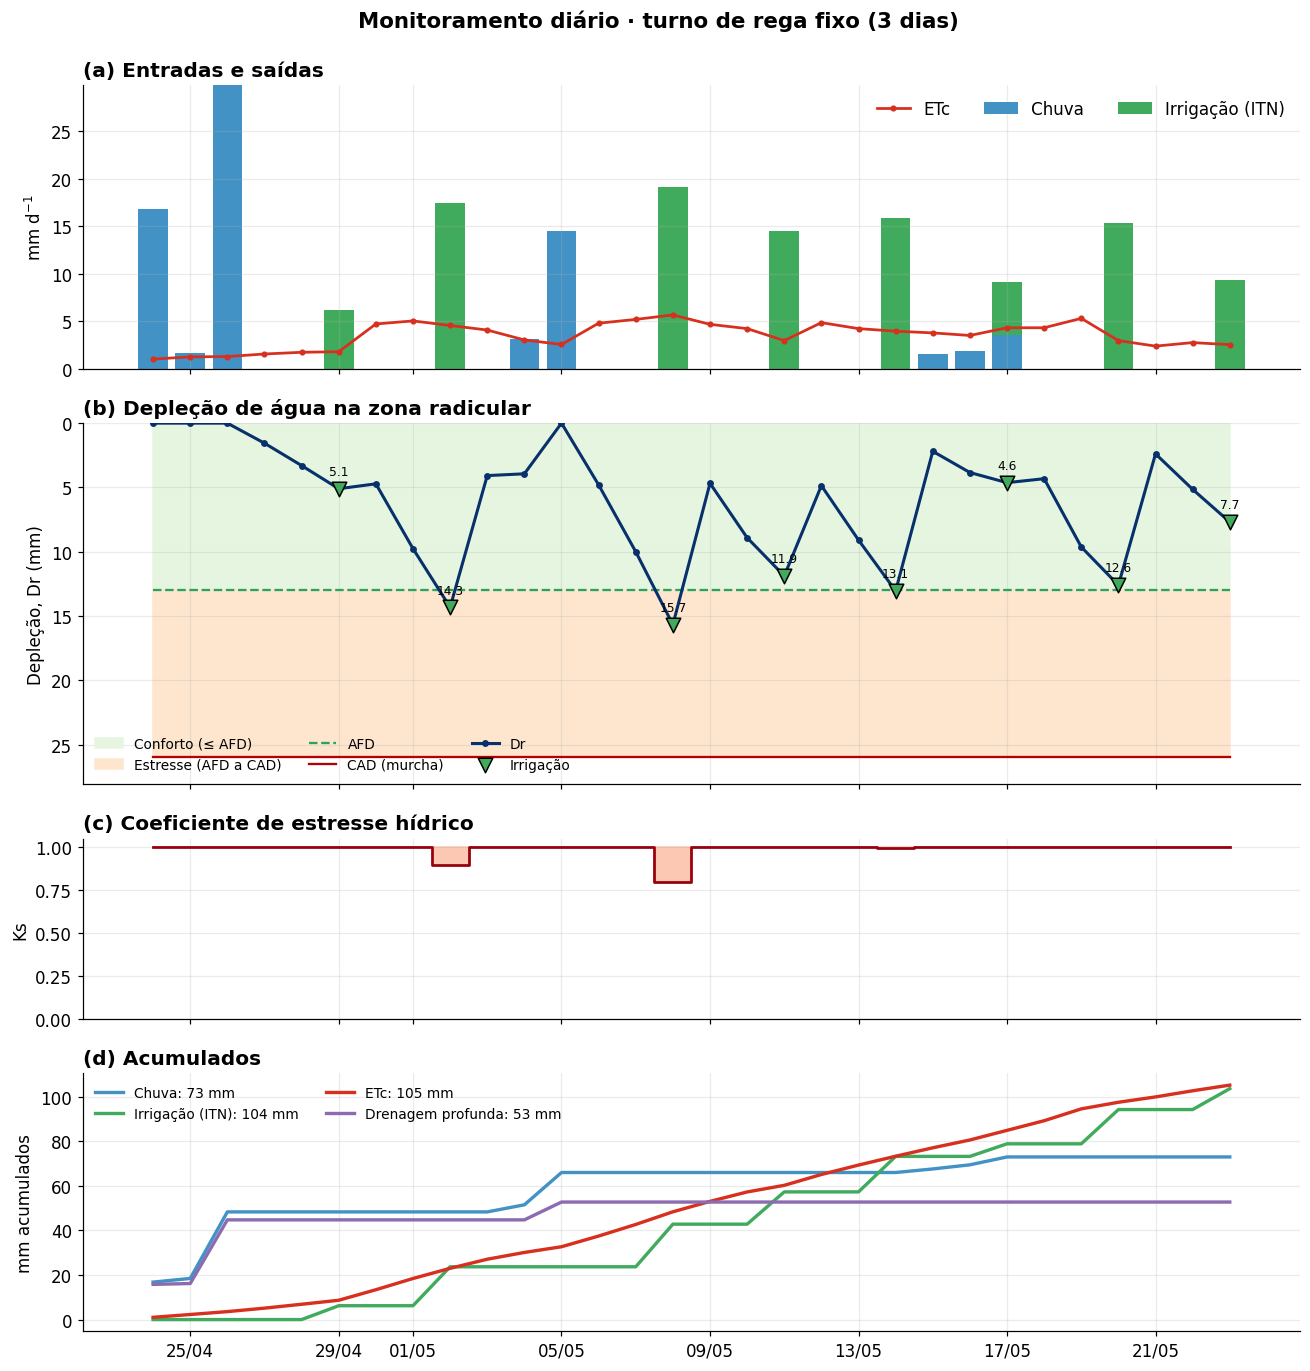

In [37]:
painel_monitoramento(trf, 'Monitoramento diário · turno de rega fixo (3 dias)',
                     'irrigacao_monitoramento_trf.png')

## 2.4 Comparação das estratégias

Figura salva em: figuras/irrigacao_comparacao.png


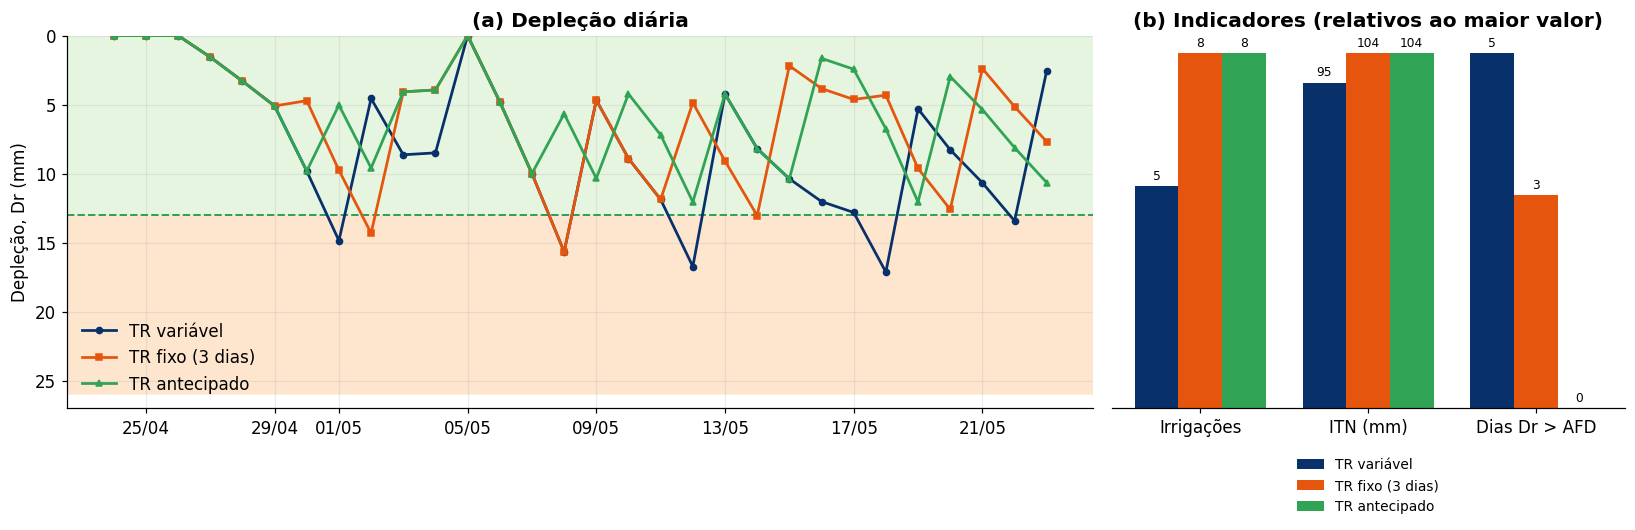

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

ax1.axhspan(0, 13, color=CORES['conforto'])
ax1.axhspan(13, 26, color=CORES['estresse'])
ax1.axhline(13, color='#2ca25f', ls='--', lw=1.3)
for b, nome, cor, est in [(trv, 'TR variável', '#08306b', 'o-'),
                          (trf, 'TR fixo (3 dias)', '#e6550d', 's-'),
                          (tra, 'TR antecipado', '#31a354', '^-')]:
    ax1.plot(b.index, b['Dr'], est, color=cor, ms=4, lw=1.8, label=nome)
ax1.set_ylim(27, 0)
ax1.set_ylabel('Depleção, Dr (mm)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax1.set_title('(a) Depleção diária', fontweight='bold')
ax1.legend(frameon=False, loc='lower left')
ax1.grid(alpha=0.25)

ind = comp.loc[['Irrigações', 'ITN total (mm)', 'Dias com Dr > AFD']].astype(float)
xs = np.arange(len(ind))
for k, (nome, cor) in enumerate(zip(comp.columns, ['#08306b', '#e6550d', '#31a354'])):
    v = ind[nome].values
    barras = ax2.bar(xs + (k - 1) * 0.26, v / ind.max(axis=1).values, width=0.26, color=cor, label=nome)
    for bb, val in zip(barras, v):
        ax2.text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.02,
                 f'{val:.0f}' if val >= 10 or val == int(val) else f'{val:.1f}',
                 ha='center', fontsize=8)
ax2.set_xticks(xs)
ax2.set_xticklabels(['Irrigações', 'ITN (mm)', 'Dias Dr > AFD'])
ax2.set_yticks([])
ax2.spines['left'].set_visible(False)
ax2.set_title('(b) Indicadores (relativos ao maior valor)', fontweight='bold')
ax2.legend(frameon=False, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=1)

plt.tight_layout()
salvar(fig, 'irrigacao_comparacao.png')
plt.show()

## 2.5 Sensibilidade ao turno de rega fixo

Como o número de irrigações, a lâmina, a drenagem e os dias de estresse mudam com TR de 1 a 6 dias?

Figura salva em: figuras/irrigacao_sensibilidade_tr.png


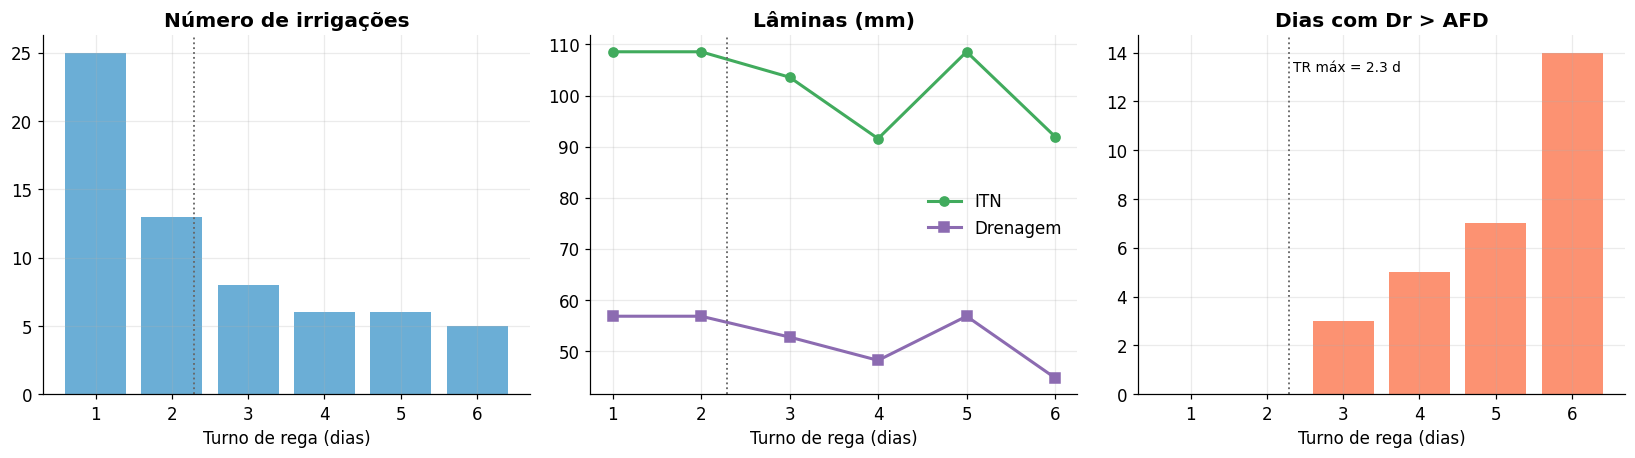

,Irrigações,IRN total (mm),ITN total (mm),Tempo total,Chuva (mm),Chuva efetiva (mm),Drenagem profunda (mm),ETc (mm),ETr (mm),Dias com Dr > AFD,Ks mínimo
TR (dias),,,,,,,,,,,
1,25,89.02,108.56,4:56,72.95,16.15,56.80,105.17,105.17,0,1.00
2,13,89.02,108.56,4:56,72.95,16.15,56.80,105.17,105.17,0,1.00
3,8,84.94,103.59,4:43,72.95,20.23,52.72,105.17,105.17,3,0.79
4,6,75.08,91.56,4:10,72.95,24.79,48.16,105.17,105.17,5,0.43
5,6,89.02,108.56,4:56,72.95,16.15,56.80,105.17,105.17,7,0.39
6,5,75.40,91.95,4:11,72.95,28.22,44.73,105.17,105.17,14,0.00


In [39]:
sens = pd.DataFrame([resumo(balanco_irrigacao(ex, CAD_EX, F_EX, 'fixo', TR=tr, Ea=EA_EX, Ia=IA_EX), tr)
                     for tr in range(1, 7)])
sens.index.name = 'TR (dias)'

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
ax[0].bar(sens.index, sens['Irrigações'], color='#6baed6')
ax[0].set_title('Número de irrigações', fontweight='bold')
ax[1].plot(sens.index, sens['ITN total (mm)'], 'o-', color=CORES['I'], lw=2, label='ITN')
ax[1].plot(sens.index, sens['Drenagem profunda (mm)'], 's-', color=CORES['DP'], lw=2, label='Drenagem')
ax[1].set_title('Lâminas (mm)', fontweight='bold')
ax[1].legend(frameon=False)
ax[2].bar(sens.index, sens['Dias com Dr > AFD'], color='#fc9272')
ax[2].set_title('Dias com Dr > AFD', fontweight='bold')
tr_max = CAD_EX * F_EX / ex['ETc'].max()
for a in ax:
    a.set_xlabel('Turno de rega (dias)')
    a.axvline(tr_max, color='0.4', ls=':', lw=1.2)
    a.grid(alpha=0.25)
ax[2].text(tr_max + 0.05, ax[2].get_ylim()[1] * 0.9, f'TR máx = {tr_max:.1f} d', fontsize=9)
plt.tight_layout()
salvar(fig, 'irrigacao_sensibilidade_tr.png')
plt.show()

sens.round(2)

# 3. Parte 2 · Monitoramento de uma safra real
___

Soja em Medianeira-PR, semeada em 01/10/2023, com dados diários do BR-DWGD (Xavier et al., 2022). A série está no repositório da disciplina.

- **ETo:** Penman-Monteith FAO-56 com a `agrometeorologiapy`.
- **Kc:** curva da FAO-56 (inicial, desenvolvimento, intermediária e final).
- **CAD:** AD do solo × profundidade radicular, crescendo de 0,2 m até Zr máx no fim da fase vegetativa.
- **AFD:** f ajustado à ETc do dia.
- **Critério:** antecipado, com ajuste de Ks no balanço e irrigação suspensa nos últimos 15 dias do ciclo (maturação).

Para comparar, o mesmo período é simulado **sem irrigação** (sequeiro).

In [40]:
URL = ('https://raw.githubusercontent.com/fcoliveira-utfpr/relacoes_fisicas_ambiente/'
       'main/roteiros/dados/xavier_Medianeira-PR_20231001_125d.csv')
LOCAL = 'xavier_Medianeira-PR_20231001_125d.csv'

try:
    clima = pd.read_csv(URL, parse_dates=['data'], index_col='data')
    print('Dados lidos do GitHub.')
except Exception:
    clima = pd.read_csv(LOCAL, parse_dates=['data'], index_col='data')
    print('Dados lidos do arquivo local.')

# ---------- Local e parâmetros ----------
LAT, ALTITUDE = -25.295, 402
SEMEADURA = pd.Timestamp('2023-10-01')
AD_SOLO = 1.0                         # água disponível (mm/cm)
ZR0, ZR_MAX = 0.20, 0.60              # profundidade radicular inicial e máxima (m)
F_SOJA = 0.50
EA, IA = 0.85, 12.0                   # pivô central: eficiência e intensidade (mm/h)
FASES = dict(ini=20, dev=30, mid=55, fim=20)          # dias (soja de 125 dias)
KC = dict(ini=0.40, mid=1.15, fim=0.50)

# ---------- ETo Penman-Monteith FAO-56 ----------
c = clima.copy()
c['Tmed'] = amp.temp_media_extremos(c['Tmax'], c['Tmin'])
nda = c.index.dayofyear
dec = amp.declinacao_solar(nda)
Hn = amp.angulo_horario_nascer(LAT, dec)
Qo = amp.irradiancia_extraterrestre(LAT, dec, Hn, amp.fator_correcao_distancia(nda))
es = (amp.es_tetens(c['Tmax']) + amp.es_tetens(c['Tmin'])) / 2
ea = amp.ea_umidade(es, c['UR'])
qcs = (0.75 + 2e-5 * ALTITUDE) * Qo
rn = amp.saldo_radiacao(amp.boc_saldo(c['Qg'], r=0.23),
                        amp.bol_saldo(c['Tmax'], c['Tmin'], ea, np.minimum(c['Qg'], qcs), qcs))
gamma = amp.constante_psicrometrica(amp.patm_altitude(ALTITUDE))
c['ETo'] = amp.eto_penman_monteith_fao56(rn, 0, c['Tmed'], c['u2'], es, ea,
                                         amp.declive_pressao_vapor(c['Tmed']), gamma).clip(lower=0)

# ---------- Kc da FAO-56 e profundidade radicular ----------
das = (c.index - SEMEADURA).days.values + 1
f1 = FASES['ini']; f2 = f1 + FASES['dev']; f3 = f2 + FASES['mid']
c['Kc'] = np.select([das <= f1, das <= f2, das <= f3],
                    [KC['ini'], KC['ini'] + (KC['mid'] - KC['ini']) * (das - f1) / FASES['dev'], KC['mid']],
                    KC['mid'] + (KC['fim'] - KC['mid']) * (das - f3) / FASES['fim'])
c['Zr'] = np.minimum(ZR0 + (ZR_MAX - ZR0) * das / f2, ZR_MAX)
c['CAD'] = AD_SOLO * c['Zr'] * 100
c['ETc'] = c['Kc'] * c['ETo']
c['P'] = c['Chuva']
c['DAE'] = das

CICLO = f3 + FASES['fim']
safra = balanco_irrigacao(c, c['CAD'], F_SOJA, 'antecipado', Ea=EA, Ia=IA,
                          f_ajustado=True, ajustar_ks=True, ultimo_dia=CICLO - 15)
sequeiro = balanco_irrigacao(c, c['CAD'], F_SOJA, 'nenhum', Ea=EA, Ia=IA,
                             f_ajustado=True, ajustar_ks=True)

pd.concat([resumo(safra, 'Irrigado (antecipado)'), resumo(sequeiro, 'Sequeiro')], axis=1)

Dados lidos do GitHub.


,Irrigado (antecipado),Sequeiro
Irrigações,8,0
IRN total (mm),175.868164,0.0
ITN total (mm),206.903723,0.0
Tempo total,17:15,—
Chuva (mm),1025.307444,1025.307444
Chuva efetiva (mm),311.792367,408.951671
Drenagem profunda (mm),713.515076,616.355773
ETc (mm),522.816407,522.816407
ETr (mm),522.816407,444.107546
Dias com Dr > AFD,1,35


Figura salva em: figuras/irrigacao_safra_irrigada.png


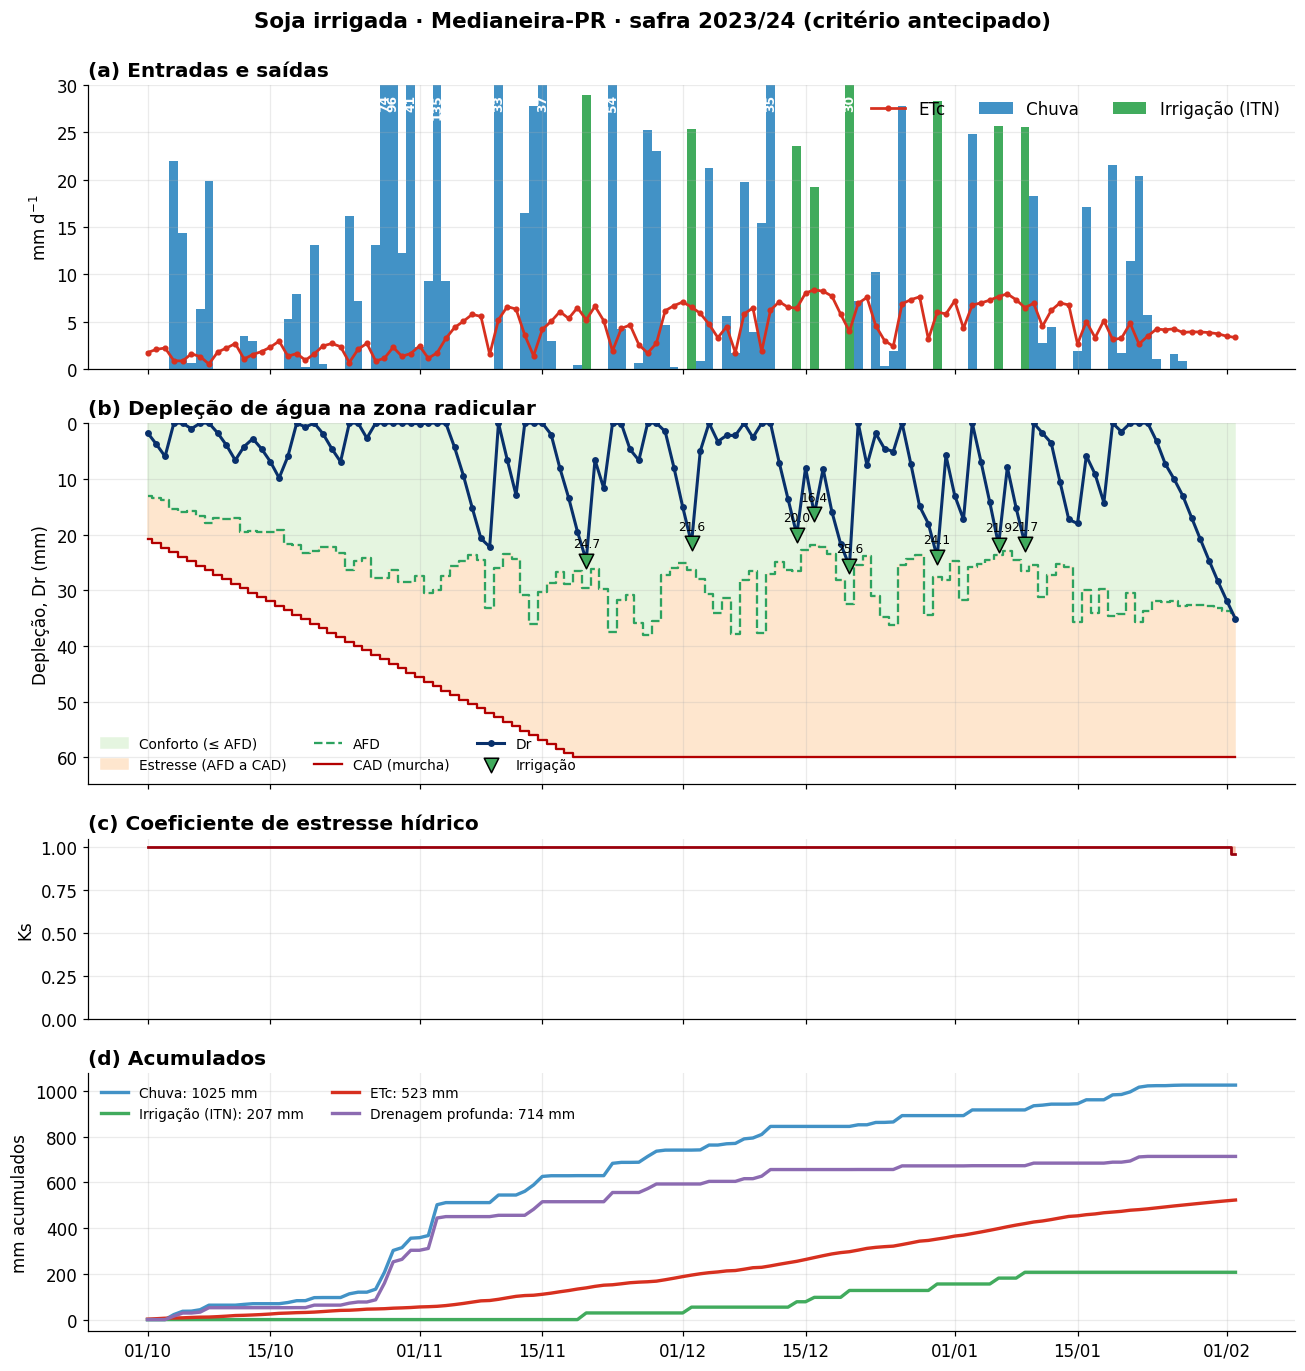

In [41]:
painel_monitoramento(safra, 'Soja irrigada · Medianeira-PR · safra 2023/24 (critério antecipado)',
                     'irrigacao_safra_irrigada.png')

Figura salva em: figuras/irrigacao_safra_sequeiro.png


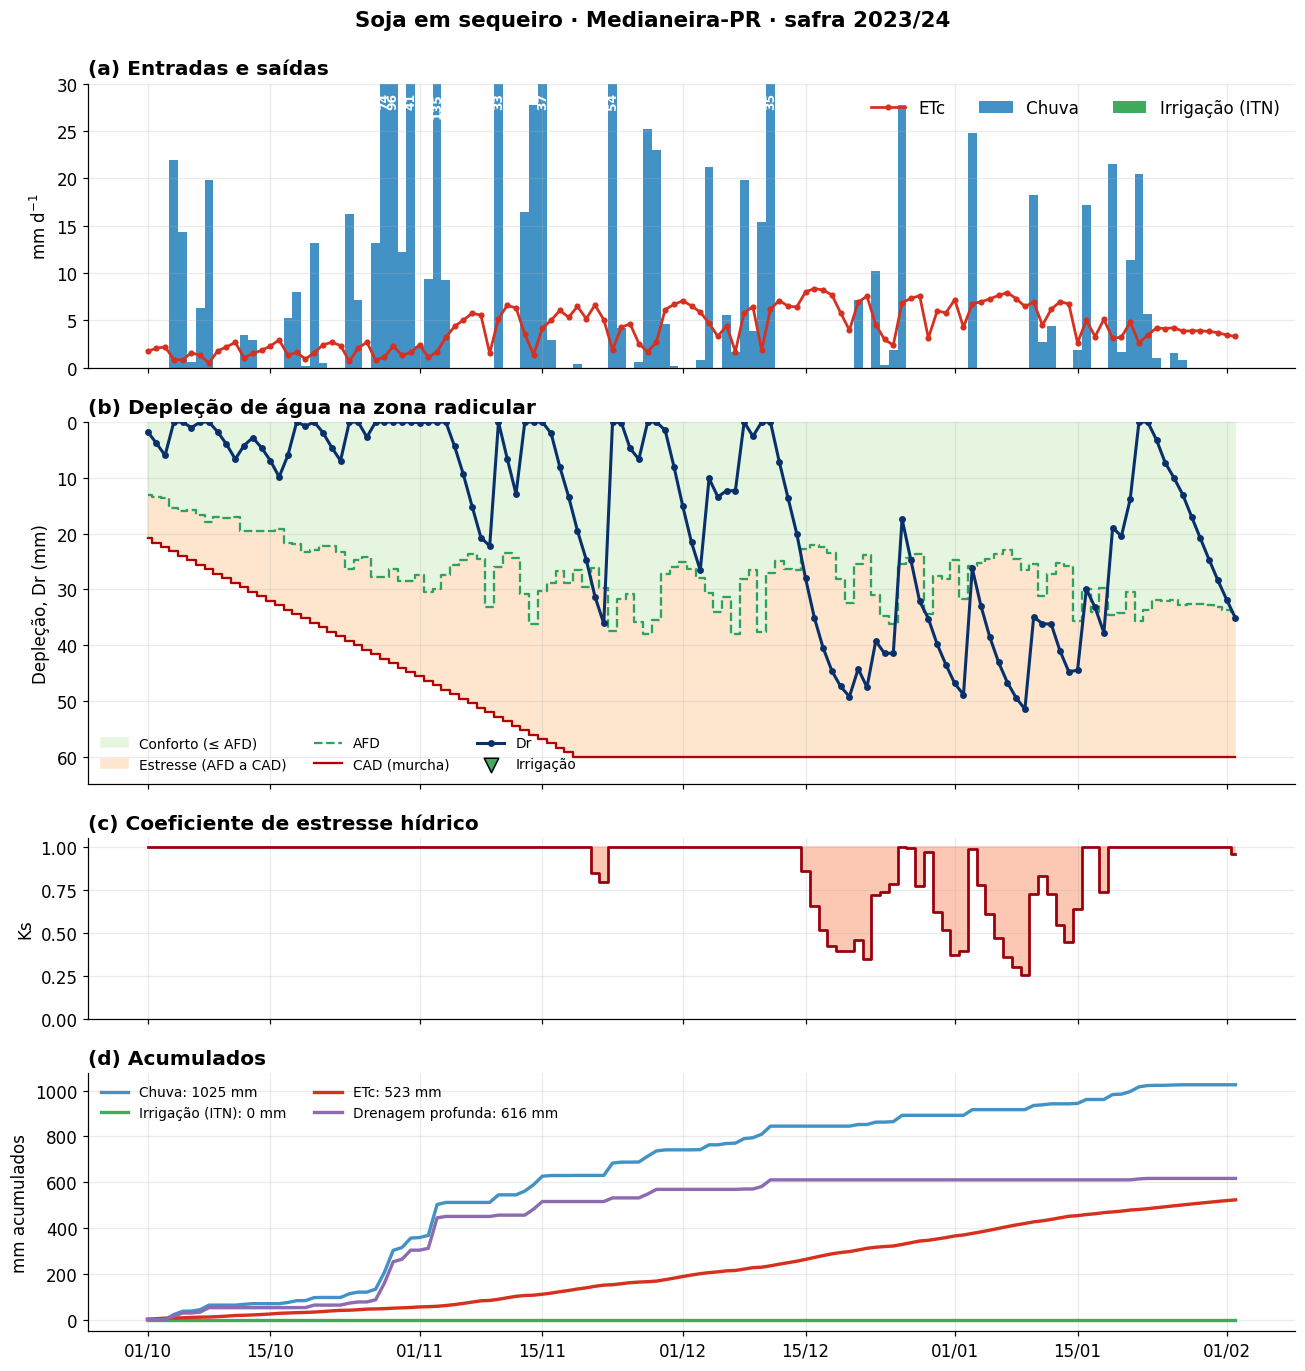

In [42]:
painel_monitoramento(sequeiro, 'Soja em sequeiro · Medianeira-PR · safra 2023/24',
                     'irrigacao_safra_sequeiro.png')

## 3.1 Calendário de irrigações da safra

A tabela que o técnico levaria a campo: data, estádio, depleção, lâminas e tempo de funcionamento do sistema.

In [43]:
def estadio(d):
    return 'Inicial' if d <= f1 else 'Desenvolvimento' if d <= f2 else 'Intermediária' if d <= f3 else 'Final'

cal = safra[safra['IRN'] > 0][['DAE', 'ETc', 'Dr', 'AFD', 'IRN', 'ITN', 'Ti']].copy()
cal.insert(1, 'Estádio', cal['DAE'].apply(estadio))
cal.index = cal.index.strftime('%d/%m/%Y')
cal.round(2)

,DAE,Estádio,ETc,Dr,AFD,IRN,ITN,Ti
data,,,,,,,,
20/11/2023,51,Intermediária,5.18,24.65,29.57,24.65,29.01,2:25
02/12/2023,63,Intermediária,6.53,21.58,26.32,21.58,25.38,2:07
14/12/2023,75,Intermediária,6.41,20.02,26.61,20.02,23.55,1:58
16/12/2023,77,Intermediária,8.35,16.36,21.95,16.36,19.25,1:36
20/12/2023,81,Intermediária,3.96,25.64,32.50,25.64,30.16,2:31
30/12/2023,91,Intermediária,6.00,24.06,27.59,24.06,28.30,2:22
06/01/2024,98,Intermediária,7.64,21.86,23.66,21.86,25.72,2:09
09/01/2024,101,Intermediária,6.47,21.70,26.47,21.70,25.52,2:08


## 3.2 Monitoramento "até hoje"

No uso real, o balanço é atualizado todo dia. A célula abaixo mostra o painel até uma data qualquer da safra, como se fosse o dia da consulta.

Situação em 05/12/2023 (DAE 66):
  Depleção atual: 3.3 mm  |  AFD: 34.1 mm  |  CAD: 60.0 mm
  Água ainda facilmente disponível: 30.8 mm
  Previsão: irrigar em cerca de 9 dia(s), mantida a ETc atual (3.3 mm/d)
Figura salva em: figuras/irrigacao_monitoramento_hoje.png


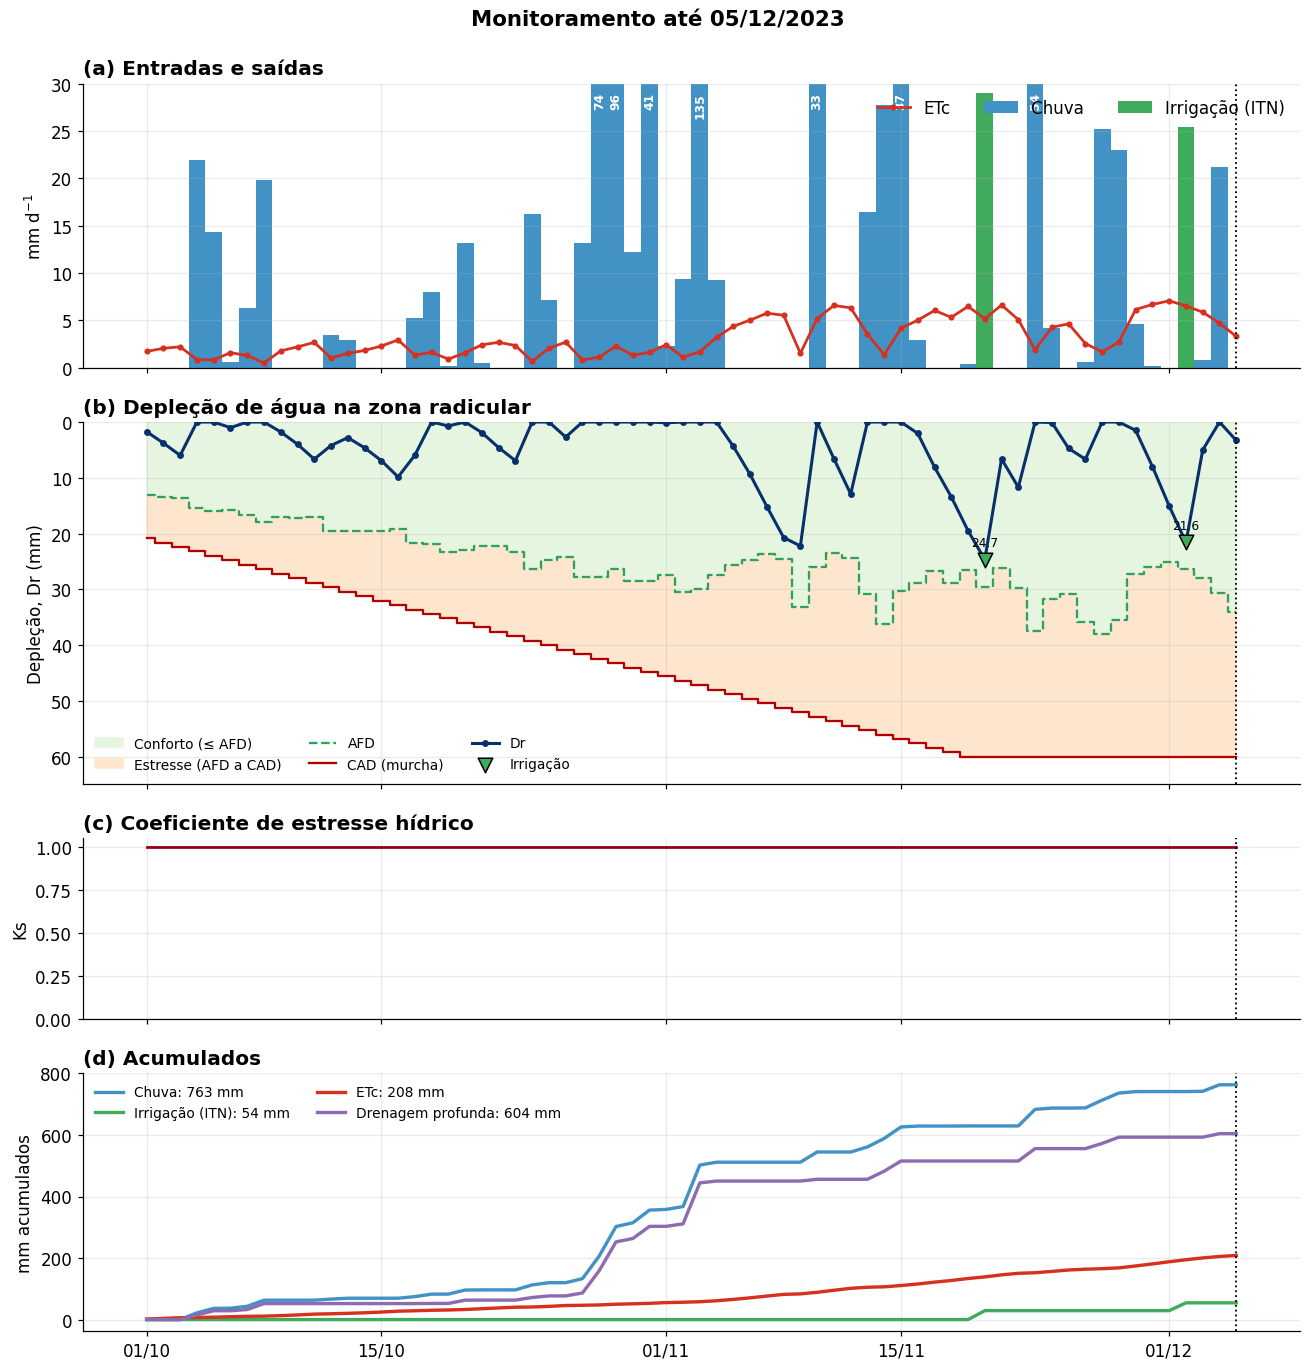

In [44]:
HOJE = '2023-12-05'           # altere para simular o acompanhamento em outra data

ate_hoje = safra.loc[:HOJE]
ultimo = ate_hoje.iloc[-1]
print(f'Situação em {pd.Timestamp(HOJE):%d/%m/%Y} (DAE {int(ultimo["DAE"])}):')
print(f'  Depleção atual: {ultimo["Dr"]:.1f} mm  |  AFD: {ultimo["AFD"]:.1f} mm  |  CAD: {ultimo["CAD"]:.1f} mm')
print(f'  Água ainda facilmente disponível: {max(0, ultimo["AFD"] - ultimo["Dr"]):.1f} mm')
dias = max(0, ultimo['AFD'] - ultimo['Dr']) / max(ultimo['ETc'], 0.1)
print(f'  Previsão: irrigar em cerca de {dias:.0f} dia(s), mantida a ETc atual ({ultimo["ETc"]:.1f} mm/d)')

painel_monitoramento(ate_hoje, f'Monitoramento até {pd.Timestamp(HOJE):%d/%m/%Y}',
                     'irrigacao_monitoramento_hoje.png', marcar_hoje=HOJE)

## Para discutir

1. No exemplo da aula, por que o critério antecipado eliminou os dias com Dr > AFD sem aumentar muito a lâmina total?
2. Na sensibilidade, a partir de qual TR os dias de estresse aparecem? Como isso se relaciona com AFD/ETc máxima?
3. Na safra real, quanto da chuva virou drenagem profunda? Em que fases isso aconteceu?
4. Compare o Ks do sequeiro com o do irrigado. Em quais fases da soja o estresse do sequeiro coincide com o ky mais alto (Aula 03)?

## Referências

ALLEN, R. G.; PEREIRA, L. S.; RAES, D.; SMITH, M. **Crop evapotranspiration**. Rome: FAO, 1998. (Irrigation and Drainage Paper, 56).

BERNARDO, S.; MANTOVANI, E. C.; SILVA, D. D.; SOARES, A. A. **Manual de irrigação**. 9. ed. Viçosa: Editora UFV, 2019.

XAVIER, A. C. et al. New improved Brazilian daily weather gridded data (1961–2020). **International Journal of Climatology**, v. 42, n. 16, p. 8390-8404, 2022.